In [59]:
import numpy as np
import librosa
from scipy.signal import find_peaks
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import pi
from scipy import signal

In [60]:
vocal_paths = {
    "Kanye West": "./song1/vocals.wav",           
    "Cardi B": "./song2/vocals.wav",              
    "Elton John": "./song3/vocals.wav",           
    "Tom Macdonald": "./song4/vocals.wav",        
    "Kanye West (AI)": "./song1/vocals_ai.wav",   
    "Cardi B (AI)": "./song2/vocals_ai.wav",      
    "Elton John (AI)": "./song3/vocals_ai.wav",   
    "Tom Macdonald (AI)": "./song4/vocals_ai.wav" 
}



max_duration = 360  

def load_audio(paths):
    out = {}
    for name, path in paths.items():
        y, sr = librosa.load(path, duration=max_duration, mono=True)
        out[name] = {"y": y, "sr": sr}
    return out

vocals = load_audio(vocal_paths)




In [61]:
def hnr(y, sr, f0, n_fft=2048, hop_length=256, n_harmonics=10, min_harmonic_energy=1e-8):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))**2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    hnr_db = np.full(S.shape[1], np.nan)
    
    for i in range(S.shape[1]):
        f0_i = f0[i] if i < len(f0) else np.nan
        mag = S[:, i]
        total_energy = np.sum(mag) + 1e-12
        if np.isnan(f0_i) or f0_i <= 0:
            continue
        harm_energy = 0.0
        for h in range(1, n_harmonics + 1):
            fh = h * f0_i
            if fh >= freqs[-1]:
                break
            bin_idx = np.argmin(np.abs(freqs - fh))
            harm_energy += mag[bin_idx]
        resid_energy = max(total_energy - harm_energy, min_harmonic_energy)
        hnr_db[i] = 10.0 * np.log10(harm_energy / resid_energy)
    return hnr_db

In [62]:
def cpp(y, frame_length=2048, hop_length=256):
    frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length).T
    window = np.hanning(frame_length)
    cpp_vals = []
    for frame in frames:
        frame = frame * window
        S = np.abs(np.fft.rfft(frame)) + 1e-12
        logS = np.log(S)
        ceps = np.fft.irfft(logS)
        peak = np.max(ceps[1:])  # skip 0-lag
        baseline = np.mean(ceps)
        cpp_vals.append(peak - baseline)
    return np.array(cpp_vals)

In [63]:
def extract_jitter_shimmer(y, sr, f0, frame_length=2048, hop_length=256):
    """
    Extract jitter (pitch period variability) and shimmer (amplitude variability)
    """
    jitter_values = []
    shimmer_values = []
    
    try:
        # Get voiced frames
        frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length).T
        
        for i, frame in enumerate(frames):
            if i >= len(f0) or np.isnan(f0[i]) or f0[i] <= 0:
                jitter_values.append(np.nan)
                shimmer_values.append(np.nan)
                continue
                
            # Calculate fundamental period in samples
            period_samples = int(sr / f0[i])
            
            if period_samples < 10 or period_samples > len(frame) // 2:
                jitter_values.append(np.nan)
                shimmer_values.append(np.nan)
                continue
            
            try:
                # Find peaks in the frame (approximate glottal pulses)
                peaks, _ = find_peaks(frame, height=np.max(frame)*0.1, distance=period_samples//2)
                
                if len(peaks) < 3:  # Need at least 3 peaks for meaningful jitter/shimmer
                    jitter_values.append(np.nan)
                    shimmer_values.append(np.nan)
                    continue
                
                # Calculate periods between consecutive peaks (jitter)
                periods = np.diff(peaks) / sr  # Convert to seconds
                if len(periods) > 1:
                    jitter = np.std(periods) / np.mean(periods)  # Relative jitter
                else:
                    jitter = np.nan
                
                # Calculate amplitude variations (shimmer)
                peak_amplitudes = frame[peaks]
                if len(peak_amplitudes) > 1:
                    amplitude_diffs = np.abs(np.diff(peak_amplitudes))
                    shimmer = np.mean(amplitude_diffs) / np.mean(peak_amplitudes)  # Relative shimmer
                else:
                    shimmer = np.nan
                
                jitter_values.append(jitter)
                shimmer_values.append(shimmer)
                
            except Exception as e:
                jitter_values.append(np.nan)
                shimmer_values.append(np.nan)
                
    except Exception as e:
        # If frame extraction fails, return arrays of NaN with same length as f0
        print(f"Warning: Jitter/shimmer extraction failed: {e}")
        jitter_values = [np.nan] * len(f0)
        shimmer_values = [np.nan] * len(f0)
    
    # Ensure we return lists, not None
    if jitter_values is None:
        jitter_values = []
    if shimmer_values is None:
        shimmer_values = []
        
    return jitter_values, shimmer_values

In [64]:
def extract_vocal_features(vocals):
    """Extract core acoustic features with established aggression relationships"""
    results = {}
    
    for name, data in vocals.items():
        y = data["y"]
        sr = data["sr"]
        
        # -----------------------------
        # 1. Pitch extraction
        # -----------------------------
        f0, voiced_flag, voiced_prob = librosa.pyin(
            y,
            fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'),
            frame_length=2048,
            hop_length=256
        )
        
        # -----------------------------
        # 2. Core acoustic feature extraction
        # -----------------------------
        S = np.abs(librosa.stft(y, n_fft=2048, hop_length=256))
        
        # SPECTRAL CENTROID ADDITION
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=2048, hop_length=256)[0]
        
        cpp_vals = cpp(y)
        hnr_db = hnr(y, sr, f0)
        
        # -----------------------------
        # 3. JITTER AND SHIMMER EXTRACTION
        # -----------------------------
        jitter_vals, shimmer_vals = extract_jitter_shimmer(y, sr, f0)
        
        # -----------------------------
        # 4. Convert to 1D arrays and align
        # -----------------------------
        f0 = np.array(f0)
        cpp_vals = np.array(cpp_vals)
        hnr_db = np.array(hnr_db)
        jitter_vals = np.array(jitter_vals)
        shimmer_vals = np.array(shimmer_vals)
        spectral_centroid = np.array(spectral_centroid)
        
        # Find the minimum length across all feature arrays
        n_frames = min(len(f0), len(cpp_vals), len(hnr_db), len(jitter_vals), 
                      len(shimmer_vals), len(spectral_centroid))
        voiced_mask = ~np.isnan(f0[:n_frames])
        
        # -----------------------------
        # 5. Compute mean features on voiced frames
        # -----------------------------
        results[name] = {
            # PITCH CHARACTERISTICS:
            "mean_f0": np.nanmean(f0[:n_frames][voiced_mask]),        # Mean fundamental frequency
            "f0_std": np.nanstd(f0[:n_frames][voiced_mask]),          # Lower = less aggressive
            
            # VOICE QUALITY FEATURES:
            "mean_hnr": np.nanmean(hnr_db[:n_frames][voiced_mask]),   # Higher = less aggressive
            "mean_cpp": np.nanmean(cpp_vals[:n_frames][voiced_mask]), # Higher = less aggressive
            
            # VOCAL INSTABILITY MEASURES:
            "mean_jitter": np.nanmean(jitter_vals[:n_frames][voiced_mask]),   # Lower = less aggressive
            "mean_shimmer": np.nanmean(shimmer_vals[:n_frames][voiced_mask]), # Lower = less aggressive
            
            # SPECTRAL CHARACTERISTICS (NEW):
            "mean_spectral_centroid": np.nanmean(spectral_centroid[:n_frames][voiced_mask]),  # Lower = less aggressive
            
            # METADATA FOR ANALYSIS:
            "is_ai": "(AI)" in name,
            "base_artist": name.split(' (AI)')[0] if '(AI)' in name else name
        }
    
    return pd.DataFrame(results).T



In [65]:
df_results = extract_vocal_features(vocals)
df_results

,mean_f0,f0_std,mean_hnr,mean_cpp,mean_jitter,mean_shimmer,mean_spectral_centroid,is_ai,base_artist
Kanye West,372.939884,422.911543,-6.961704,0.603677,0.275947,0.33919,3112.048717,False,Kanye West
Cardi B,250.01143,72.565315,-7.593393,0.652712,0.308512,0.350941,3081.362153,False,Cardi B
Elton John,504.767336,471.176579,-8.815306,0.875004,0.287068,0.344162,2547.408139,False,Elton John
Tom Macdonald,231.105705,201.37769,-7.697187,0.573298,0.317441,0.381943,3440.020473,False,Tom Macdonald
Kanye West (AI),318.934367,139.183707,-5.690197,0.696583,0.278053,0.3502,2868.459295,True,Kanye West
Cardi B (AI),270.232255,61.581149,-5.879293,0.575972,0.263473,0.31829,3172.436159,True,Cardi B
Elton John (AI),336.65331,190.415916,-5.572139,0.832651,0.240761,0.305814,2172.787725,True,Elton John
Tom Macdonald (AI),349.793215,175.932897,-7.19594,0.585378,0.293482,0.325817,3131.679555,True,Tom Macdonald


HNR: higher HNR means cleaner, harmonic voice higher = less aggresive

Pitch variability (f0_std), unstable pitch, lower = less aggerssive

mean flatness, noisy chaotic, lower = less aggressive

mean_cpp, clear vibration, higher = less aggressive

mean_voiced_prob, stable voicing, higher = less aggressive.


In [66]:
df_results.to_csv("pitch_features.csv")

In [67]:
df = df_results

In [68]:
df

,mean_f0,f0_std,mean_hnr,mean_cpp,mean_jitter,mean_shimmer,mean_spectral_centroid,is_ai,base_artist
Kanye West,372.939884,422.911543,-6.961704,0.603677,0.275947,0.33919,3112.048717,False,Kanye West
Cardi B,250.01143,72.565315,-7.593393,0.652712,0.308512,0.350941,3081.362153,False,Cardi B
Elton John,504.767336,471.176579,-8.815306,0.875004,0.287068,0.344162,2547.408139,False,Elton John
Tom Macdonald,231.105705,201.37769,-7.697187,0.573298,0.317441,0.381943,3440.020473,False,Tom Macdonald
Kanye West (AI),318.934367,139.183707,-5.690197,0.696583,0.278053,0.3502,2868.459295,True,Kanye West
Cardi B (AI),270.232255,61.581149,-5.879293,0.575972,0.263473,0.31829,3172.436159,True,Cardi B
Elton John (AI),336.65331,190.415916,-5.572139,0.832651,0.240761,0.305814,2172.787725,True,Elton John
Tom Macdonald (AI),349.793215,175.932897,-7.19594,0.585378,0.293482,0.325817,3131.679555,True,Tom Macdonald


In [69]:
sns.set(style="whitegrid", palette="muted", font_scale=1.2)


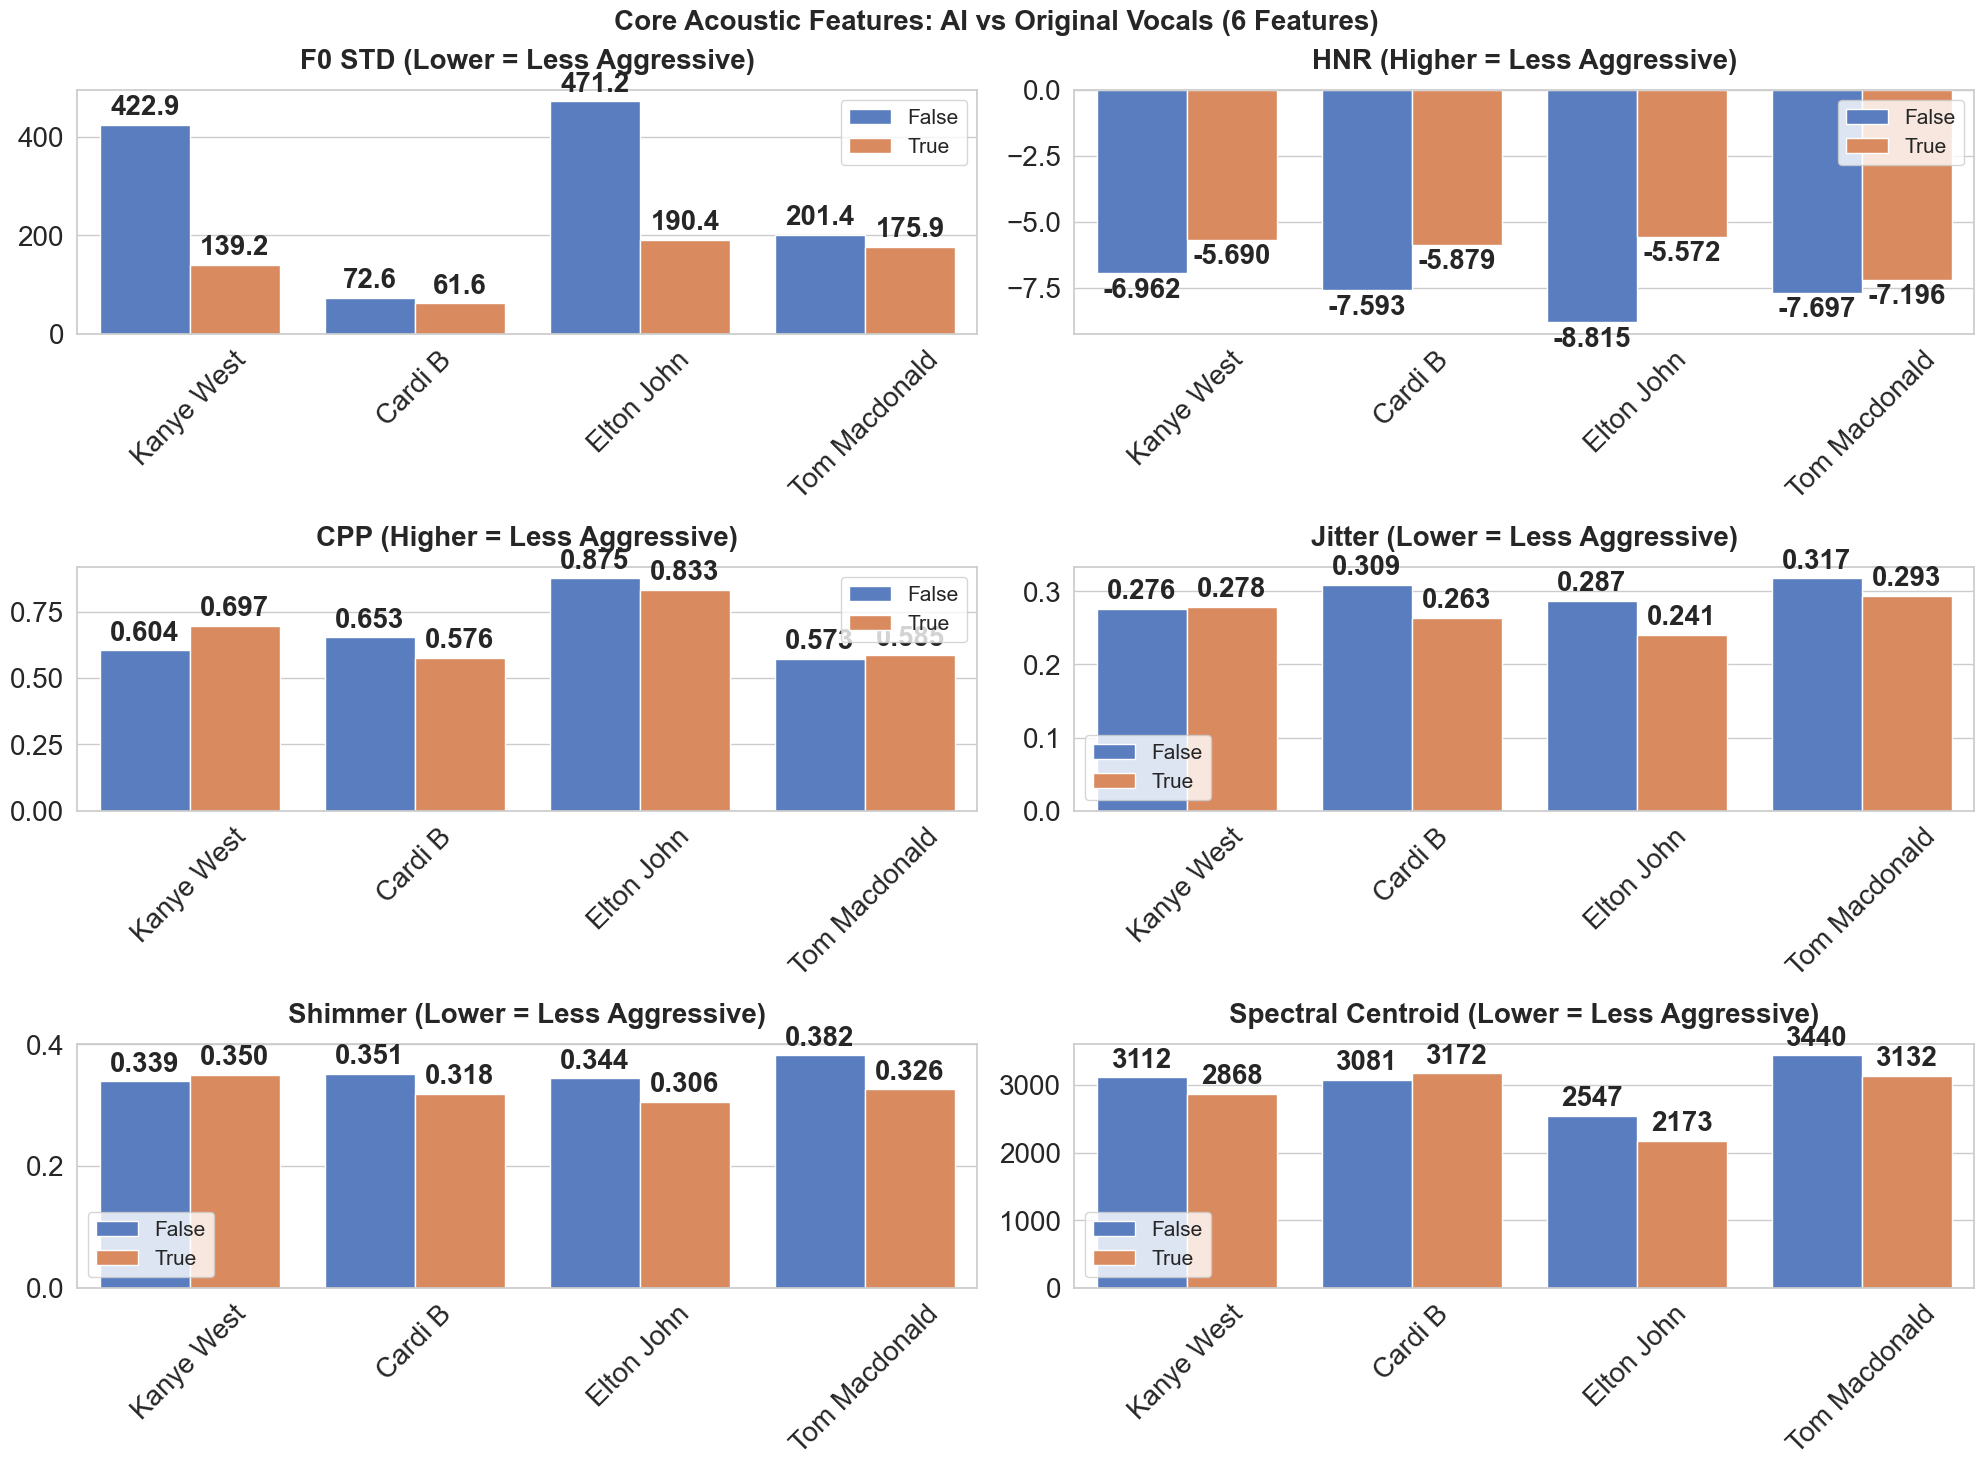

<Figure size 1800x1000 with 0 Axes>

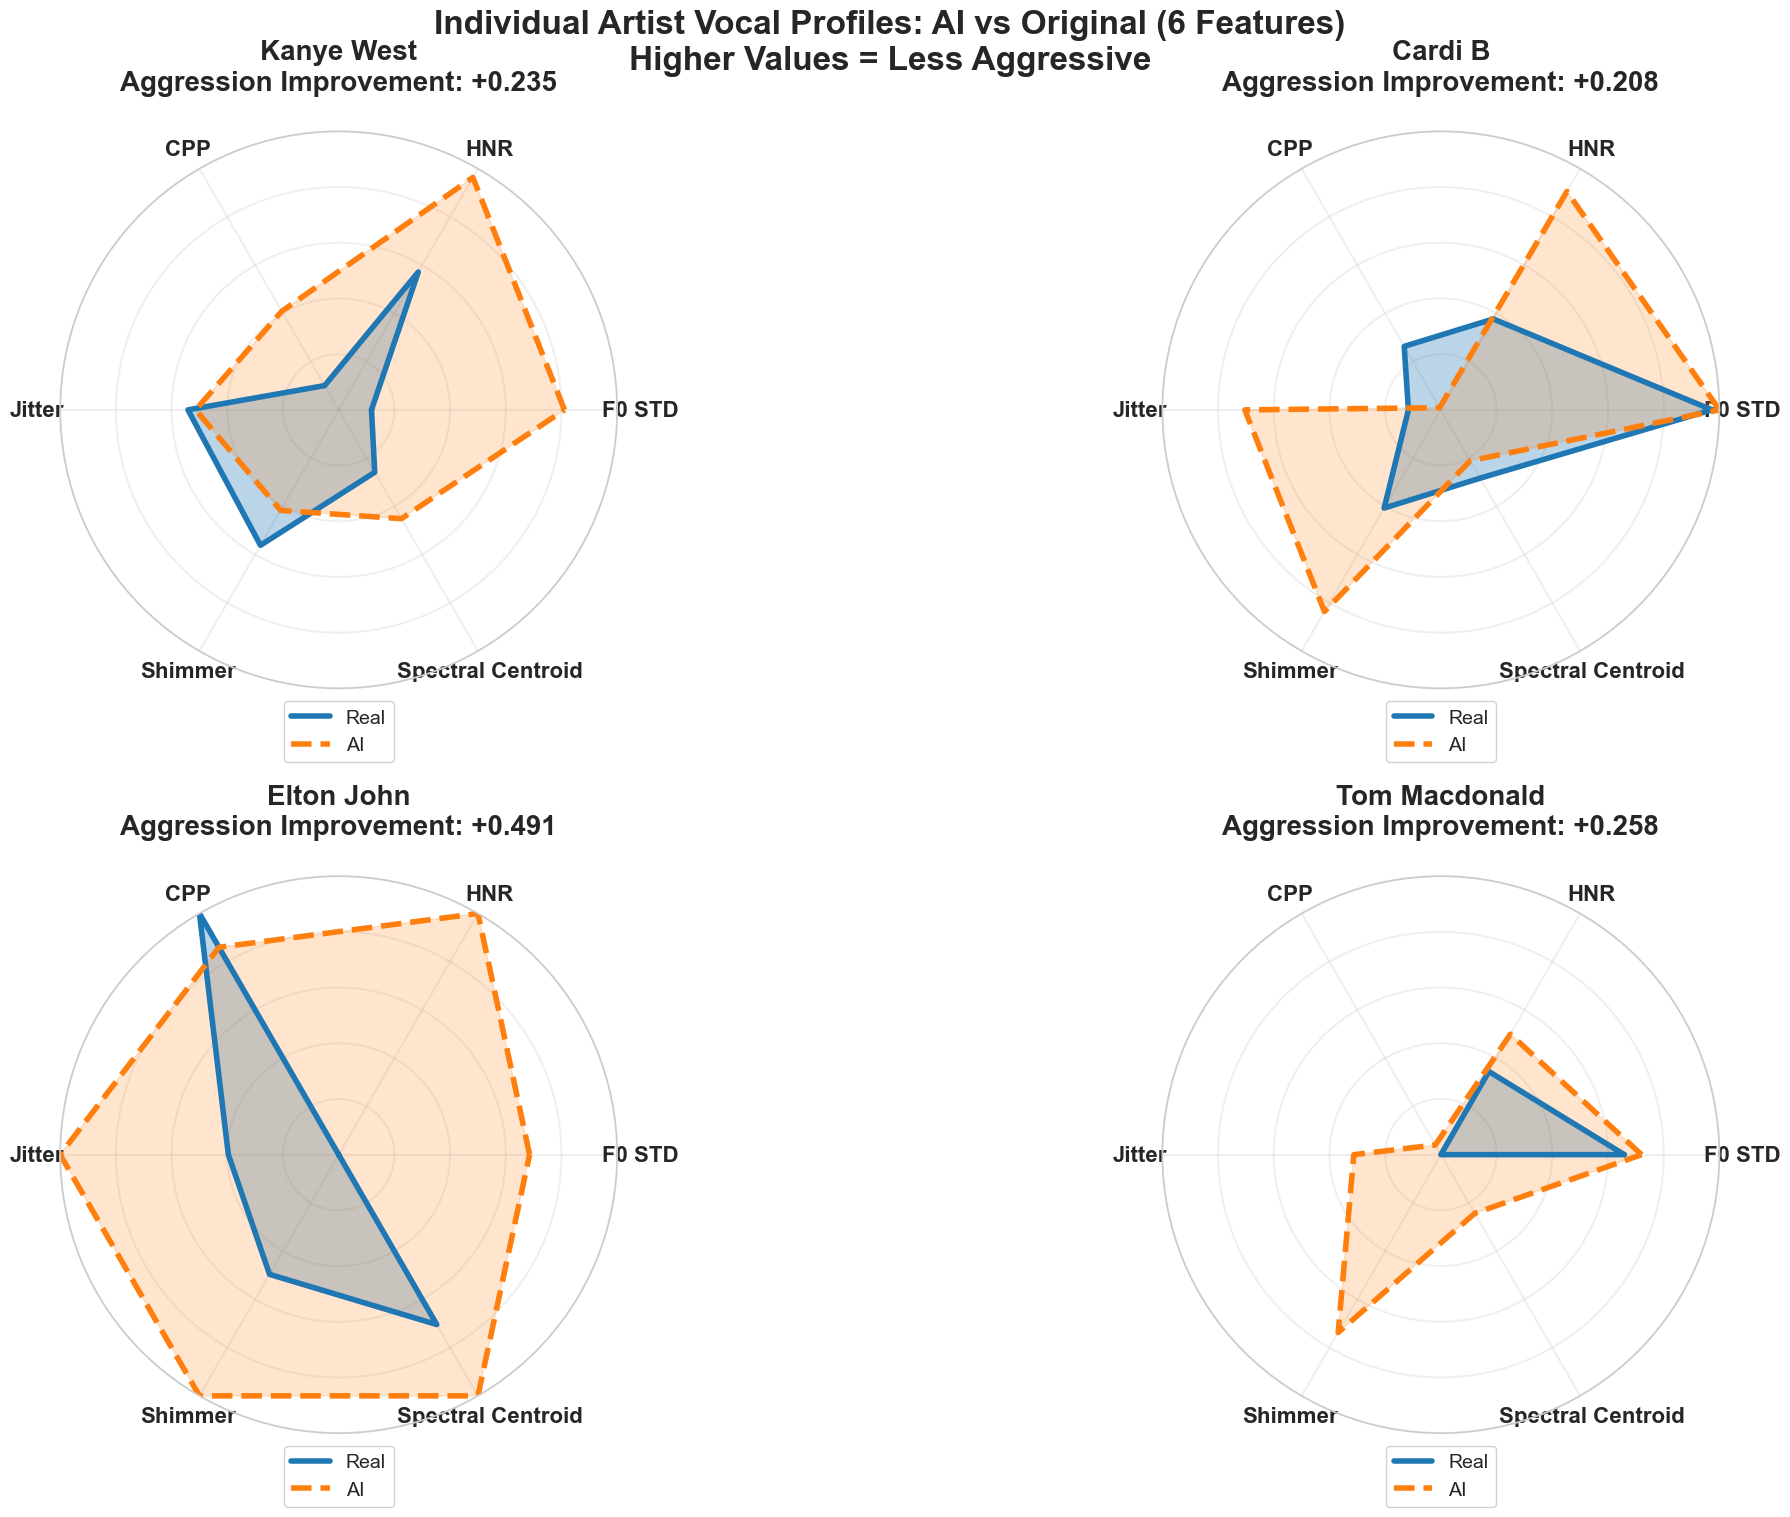

<Figure size 1600x800 with 0 Axes>

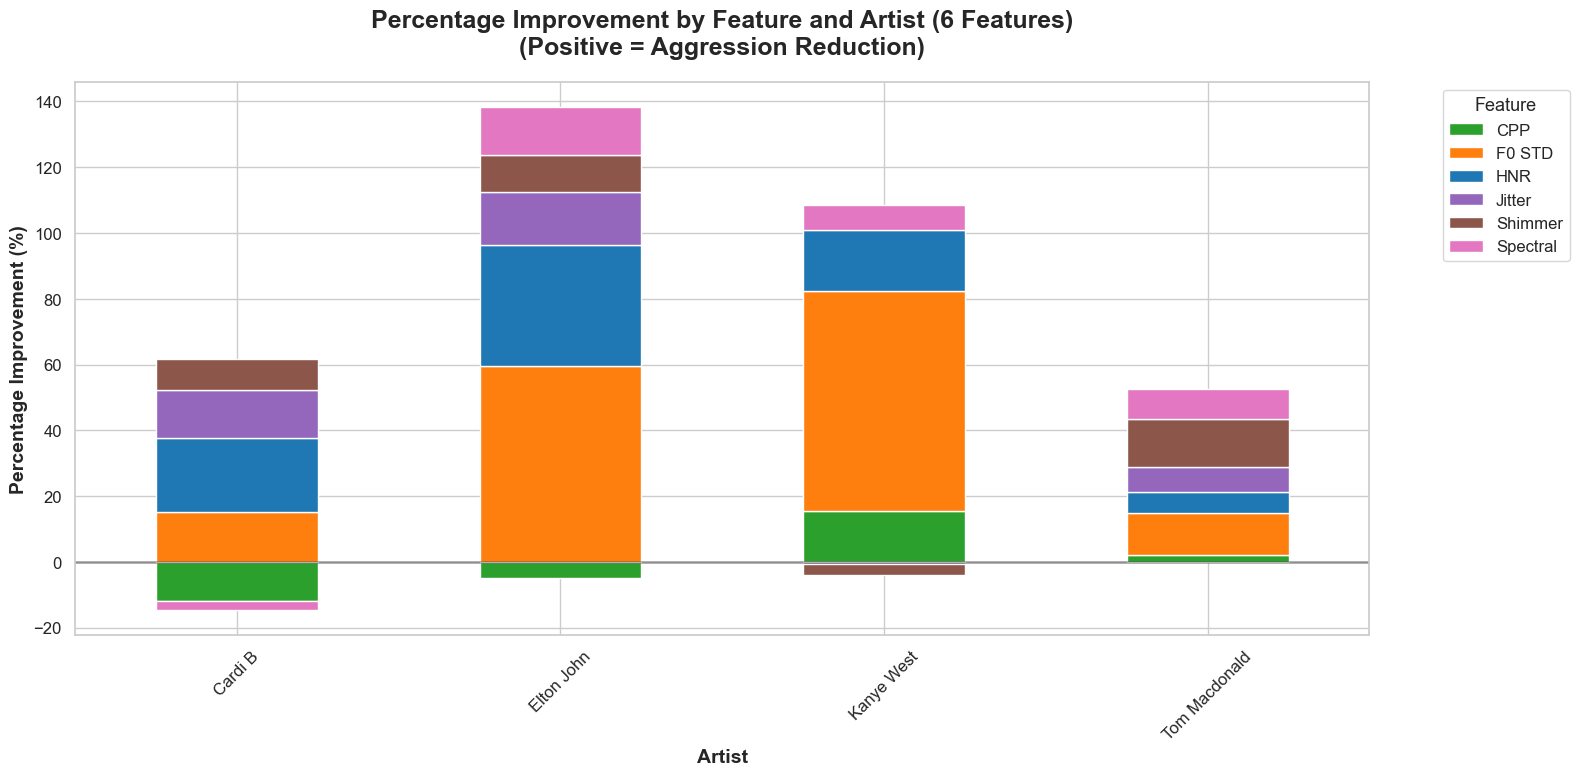

In [72]:
artists = df['base_artist'].unique()

# --- Focused Barplots: Six Core Features ---
fig, axes = plt.subplots(3, 2, figsize=(20, 15))  # Increased height for 3x2 layout

core_features = ['f0_std', 'mean_hnr', 'mean_cpp', 'mean_jitter', 'mean_shimmer', 'mean_spectral_centroid']
core_names = [
    'F0 STD (Lower = Less Aggressive)', 
    'HNR (Higher = Less Aggressive)', 
    'CPP (Higher = Less Aggressive)', 
    'Jitter (Lower = Less Aggressive)',
    'Shimmer (Lower = Less Aggressive)',
    'Spectral Centroid (Lower = Less Aggressive)'
]

for idx, (feature, name) in enumerate(zip(core_features, core_names)):
    # Correct indexing for 3x2 grid: use idx//2 for rows, idx%2 for columns
    ax = axes[idx//2, idx%2]
    sns.barplot(data=df, x="base_artist", y=feature, hue="is_ai", ax=ax)
    ax.set_title(name, fontsize=20, fontweight='bold', pad=15)  # Larger title
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=20)  # Larger x-axis labels
    ax.tick_params(axis='y', labelsize=20)  # Larger y-axis labels
    ax.legend(fontsize=15)  # Larger legend
    
    # Add value annotations with larger text
    for container in ax.containers:
        if feature == 'f0_std':  # F0 std values are larger, use 1 decimal
            ax.bar_label(container, fmt='%.1f', padding=3, fontsize=20, fontweight='bold')
        elif feature == 'mean_spectral_centroid':  # Spectral centroid also larger
            ax.bar_label(container, fmt='%.0f', padding=3, fontsize=20, fontweight='bold')
        else:  # Other features use 3 decimals
            ax.bar_label(container, fmt='%.3f', padding=3, fontsize=20, fontweight='bold')

plt.suptitle('Core Acoustic Features: AI vs Original Vocals (6 Features)', fontsize=20, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Paired Comparison Plot with 6 Features ---
plt.figure(figsize=(18, 10))  # Larger figure

# Prepare data for paired lines
paired_data = []
for artist in artists:
    real_row = df[(df['base_artist'] == artist) & (~df['is_ai'])].iloc[0]
    ai_row = df[(df['base_artist'] == artist) & (df['is_ai'])].iloc[0]
    
    for feature, name in zip(core_features, core_names):
        paired_data.append({
            'Artist': artist, 'Feature': name, 'Type': 'Real', 
            'Value': real_row[feature]
        })
        paired_data.append({
            'Artist': artist, 'Feature': name, 'Type': 'AI', 
            'Value': ai_row[feature]
        })

paired_df = pd.DataFrame(paired_data)


# --- Radar Chart with 6 Features ---
fig, axes = plt.subplots(2, 2, figsize=(24, 16), subplot_kw=dict(polar=True))  # 2x2 layout for 4 artists
axes = axes.flatten()

categories = [
    'F0 STD', 
    'HNR', 
    'CPP', 
    'Jitter',
    'Shimmer',
    'Spectral Centroid'
]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the circle

# Normalize features for radar chart
df_radar = df.copy()
for feature in ['mean_hnr', 'mean_cpp']:
    df_radar[f'{feature}_norm'] = (df_radar[feature] - df_radar[feature].min()) / (df_radar[feature].max() - df_radar[feature].min())

# For features where lower = better, invert normalization
for feature in ['f0_std', 'mean_jitter', 'mean_shimmer', 'mean_spectral_centroid']:
    df_radar[f'{feature}_norm'] = 1 - (df_radar[feature] - df_radar[feature].min()) / (df_radar[feature].max() - df_radar[feature].min())

for idx, artist in enumerate(artists):
    ax = axes[idx]
    
    real_row = df_radar[(df_radar['base_artist'] == artist) & (~df_radar['is_ai'])].iloc[0]
    ai_row = df_radar[(df_radar['base_artist'] == artist) & (df_radar['is_ai'])].iloc[0]
    
    values_real = [
        real_row['f0_std_norm'],
        real_row['mean_hnr_norm'],
        real_row['mean_cpp_norm'],
        real_row['mean_jitter_norm'],
        real_row['mean_shimmer_norm'],
        real_row['mean_spectral_centroid_norm']
    ]
    values_real += values_real[:1]
    
    values_ai = [
        ai_row['f0_std_norm'],
        ai_row['mean_hnr_norm'],
        ai_row['mean_cpp_norm'],
        ai_row['mean_jitter_norm'],
        ai_row['mean_shimmer_norm'],
        ai_row['mean_spectral_centroid_norm']
    ]
    values_ai += values_ai[:1]
    
    # Plot real vocal (solid line)
    ax.plot(angles, values_real, linewidth=4, label='Real', color='#1f77b4')
    ax.fill(angles, values_real, alpha=0.3, color='#1f77b4')
    
    # Plot AI vocal (dashed line)
    ax.plot(angles, values_ai, linewidth=4, label='AI', color='#ff7f0e', linestyle='--')
    ax.fill(angles, values_ai, alpha=0.2, color='#ff7f0e')
    
    # Configure the chart with MUCH larger text
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=16, fontweight='bold')  # Even larger category labels
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, linewidth=1.5)
    
    # Calculate improvement area (now all features contribute to aggression assessment)
    aggression_improvement = sum([values_ai[i] - values_real[i] for i in range(len(values_real)-1)]) / (len(values_real)-1)
    
    ax.set_title(f'{artist}\nAggression Improvement: {aggression_improvement:+.3f}', size=20, pad=30, fontweight='bold')  # Larger title
    
    # Move legend down to avoid overlapping with HNR label - using lower center position
    ax.legend(loc='lower center', fontsize=14, framealpha=0.9, bbox_to_anchor=(0.5, -0.15))

plt.suptitle('Individual Artist Vocal Profiles: AI vs Original (6 Features)\nHigher Values = Less Aggressive', 
             size=24, y=0.95, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Stacked Bar Chart: Feature Contributions (6 Features) ---
plt.figure(figsize=(16, 8))  # Larger figure

# Prepare stacked data
stacked_data = []
for artist in artists:
    real_row = df[(df['base_artist'] == artist) & (~df['is_ai'])].iloc[0]
    ai_row = df[(df['base_artist'] == artist) & (df['is_ai'])].iloc[0]
    
    # Calculate normalized improvements
    hnr_imp = (ai_row['mean_hnr'] - real_row['mean_hnr']) / abs(real_row['mean_hnr']) * 100
    cpp_imp = (ai_row['mean_cpp'] - real_row['mean_cpp']) / abs(real_row['mean_cpp']) * 100
    jitter_imp = (real_row['mean_jitter'] - ai_row['mean_jitter']) / real_row['mean_jitter'] * 100  # Inverted
    shimmer_imp = (real_row['mean_shimmer'] - ai_row['mean_shimmer']) / real_row['mean_shimmer'] * 100  # Inverted
    spectral_imp = (real_row['mean_spectral_centroid'] - ai_row['mean_spectral_centroid']) / real_row['mean_spectral_centroid'] * 100  # Inverted
    # F0 STD: show improvement (lower = better)
    f0_std_imp = (real_row['f0_std'] - ai_row['f0_std']) / real_row['f0_std'] * 100  # Inverted
    
    stacked_data.append({'Artist': artist, 'Feature': 'HNR', 'Improvement_Percent': hnr_imp})
    stacked_data.append({'Artist': artist, 'Feature': 'CPP', 'Improvement_Percent': cpp_imp})
    stacked_data.append({'Artist': artist, 'Feature': 'Jitter', 'Improvement_Percent': jitter_imp})
    stacked_data.append({'Artist': artist, 'Feature': 'Shimmer', 'Improvement_Percent': shimmer_imp})
    stacked_data.append({'Artist': artist, 'Feature': 'Spectral', 'Improvement_Percent': spectral_imp})
    stacked_data.append({'Artist': artist, 'Feature': 'F0 STD', 'Improvement_Percent': f0_std_imp})

stacked_df = pd.DataFrame(stacked_data)

# Create stacked bar chart with larger text
pivot_df = stacked_df.pivot(index='Artist', columns='Feature', values='Improvement_Percent')
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(16, 8), 
                   color=['#2ca02c', '#ff7f0e', '#1f77b4', '#9467bd', '#8c564b', '#e377c2'])
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=2)
plt.ylabel('Percentage Improvement (%)', fontsize=14, fontweight='bold')
plt.xlabel('Artist', fontsize=14, fontweight='bold')
plt.title('Percentage Improvement by Feature and Artist (6 Features)\n(Positive = Aggression Reduction)', 
          fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=13)
plt.tight_layout()
plt.show()